<a href="https://colab.research.google.com/github/luciavilchez23/SimulacionPAS/blob/main/Simulaci%C3%B3nGPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación y visualización de Procesos Gaussianos

El objetivo es simular trayectorias de Procesos Gaussianos para acabar generando las imágenes de las diapositivas de teoría.

In [ ]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante

Se deben obtener 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3x3})$.

Para ello se usa la función `np.random.multivariate_normal` que sirve para generar muestras aleatorias de una distribución normal multivariante. Genera vectores aleatorios $\textbf{x}$ que siguen una distribución normal $\mathcal{N}(\mu,\sum)$.

In [ ]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.eye(3)
num_samples = 50

# Aplicamos sobre estos argumentos la función
samples = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

# Visualizamos lo que hemos obtenido
print("Shape: ", samples.shape) # tamaño
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 1.42710049  0.94284807  0.06977614]
 [ 0.50281781 -0.77749287  1.34882498]
 [ 1.13828524 -0.04806683 -1.49478587]
 [-0.02543796  0.13050287 -0.16938116]
 [ 0.75214387 -0.61894623  1.40877141]
 [-1.57791091 -0.37963162 -0.08516914]
 [-0.81120993  0.97807214  0.40908835]
 [ 0.7750923  -1.56441338  1.42693827]
 [ 1.55424954  0.5164351   0.63859676]
 [-0.17612257 -0.10134076  0.18070294]
 [ 1.07336251 -0.87195239  0.44324888]
 [ 1.82445007  1.06312265 -0.88276254]
 [-1.13988995  0.41048686 -1.07451038]
 [ 0.32359395  1.95984039 -1.28795069]
 [-0.49385603  0.37335365 -0.2725986 ]
 [ 0.30767081  1.01448272 -0.96534452]
 [ 1.30902082 -2.08842312  0.88006856]
 [ 1.21998224 -0.6523096   0.05113594]
 [-0.39213901  1.5857227  -1.08790856]
 [ 1.71332163  0.78153766 -0.82768778]
 [-0.910708   -0.12494078  1.44155851]
 [-1.71806451 -1.06222898 -0.22324259]
 [ 0.99825096 -0.75278952  0.48468867]
 [ 0.20285914  0.53459533  0.24799877]
 [-0.68863708 -1.96311261 -0.27000863

Hago ahora lo mismo pero para una normal con matriz de covarianzas que no es la identidad $$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$

In [ ]:
vector_medias = np.zeros(3)
matriz_covarianzas = np.diag((1,10,100))
num_samples = 50

samples2 = np.random.multivariate_normal(vector_medias, matriz_covarianzas, num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples2)

Shape:  (50, 3)
Muestras: 
[[-5.00076903e-01 -4.60469971e-01  1.17387717e+01]
 [ 1.68132275e-01 -8.29065854e-01  2.63550564e+01]
 [ 1.44637752e+00 -2.14319767e+00  1.06586420e+01]
 [ 1.49556230e+00  1.28955165e-02 -3.23622132e+00]
 [-4.06971932e-01 -2.14569518e+00 -6.20211386e+00]
 [-1.57933698e-01  2.36006113e+00 -1.51218872e+00]
 [ 1.16280829e+00 -1.07113817e+00 -1.11299752e+01]
 [ 3.16117840e-01  1.33503186e+00  2.50765588e+00]
 [ 3.25040326e-02  1.74610951e+00 -1.27568286e+01]
 [ 1.27580955e+00 -2.26939783e+00 -1.59958828e+01]
 [ 1.71537119e+00  1.87155064e+00 -1.41701647e+01]
 [ 1.38649285e+00  2.53024187e+00 -1.54075082e+01]
 [ 5.38997829e-01 -4.29966651e+00  2.22398294e+00]
 [-4.48050197e-01 -5.66584154e-01  2.01407420e+01]
 [-1.77547956e-01 -1.04007927e+00 -2.21211180e+01]
 [ 4.44590034e-01 -4.19052116e+00  1.54050138e+01]
 [ 7.44474252e-02  4.04644078e-01 -5.57030509e+00]
 [ 6.26217544e-01 -2.54932231e+00  7.40048616e+00]
 [-1.59188769e-01 -1.86022596e+00  3.38203646e+00]
 [ 1

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular un GP con kernel RBF, además lo usaremos para generar las imágenes de las diapositivas. Usaremos función de medias constantemente igual a cero.

La función de covarianzas RBF (radial basis function), se define como:

$$
  k: TxT\to \mathbb{R} \\
  k(t_1,t_2)=\sigma^2 \exp(-\frac{1}{2}(\frac{t_1-t_2}{l})^2)
$$
donde $l$ y $\sigma^2$ son parámetros.

In [ ]:
# Definición de la función principal
def simular_GP_RBF(t, sigma=1, lengthscale=1, num_samples=1):

  # Comprobación de que los datos proporcionados son correctos
  if t.ndim != 1:
    raise ValueError("t debe ser un vector")
  if lengthscale <= 0:
    raise ValueError("lengthscale debe ser un valor positivo")

  # Paso 1: calcula el vector de medias
  vector_medias = np.zeros_like(t)

  # Paso 2: calcula la matriz de covarianzas
  d = t[:, None] - t[None, :] # matriz de diferencias usando broadcasting de Numpy
  matriz_covs = sigma**2 * np.exp(-0.5*(d/lengthscale)**2)

  # Paso 3: obtener las simulaciones del GP
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)

  return samples

Utilizo ahora esta función para generar imágenes como las de las diapositivas 59 y 62.

<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3248/3487929960.py:28: SyntaxWarning: invalid escape sequence '\s'
  plt.title('GP con kernel RBF para $\sigma$=0.25')
/tmp/ipykernel_3248/3487929960.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.title('GP con kernel RBF para $\sigma$=1')
/tmp/ipykernel_3248/3487929960.py:50: SyntaxWarning: invalid escape sequence '\s'
  plt.title('GP con kernel RBF para $\sigma$=4')


Text(0.5, 1.0, 'GP con kernel RBF para $\\sigma$=4')

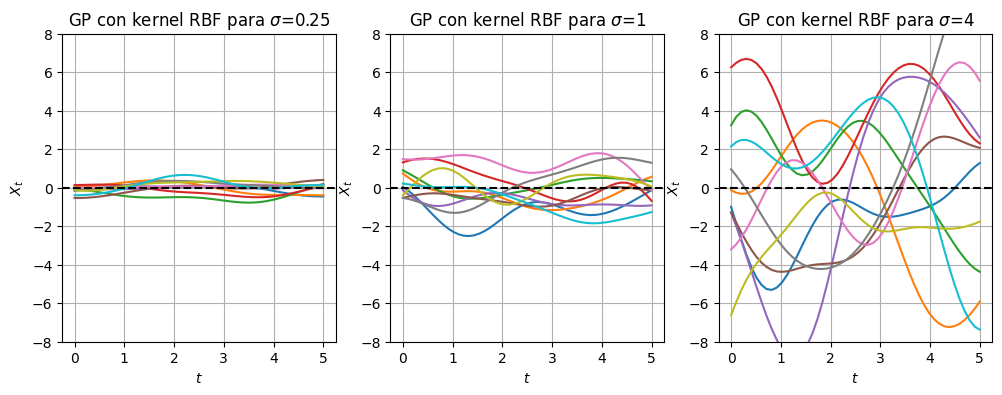

In [ ]:
# DIAPOSITIVA 59

# Generamos el vector t
t = np.linspace(0, 5, 50)

# Hacemos la simulación con la función definida
sigma1 = 0.25
sigma2 = 1
sigma3 = 4
lengthscale = 1
num_samples = 10
samples1 = simular_GP_RBF(t, sigma1, lengthscale, num_samples)
samples2 = simular_GP_RBF(t, sigma2, lengthscale, num_samples)
samples3 = simular_GP_RBF(t, sigma3, lengthscale, num_samples)

# Vamos a visualizarlo usando subplot donde el primer argumento es el numero de filas, el segundo el numero de columnas y el tercero donde quieres colocar la grafica que se va a imprimir
plt.figure(figsize=(12,4)) # Tamaño de la figura

plt.subplot(1,3,1) # Gráfica 1
for i in range(num_samples):
  plt.plot(t, samples1[i])

plt.grid(True)
plt.ylim(-8,8)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP con kernel RBF para $\sigma$=0.25')

plt.subplot(1,3,2) # Gráfica 2
for i in range(num_samples):
  plt.plot(t, samples2[i])

plt.grid(True)
plt.ylim(-8,8)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP con kernel RBF para $\sigma$=1')

plt.subplot(1,3,3) # Gráfica 3
for i in range(num_samples):
  plt.plot(t, samples3[i])

plt.grid(True)
plt.ylim(-8,8)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP con kernel RBF para $\sigma$=4')

Text(0.5, 1.0, 'GP con kernel RBF para $l=4$')

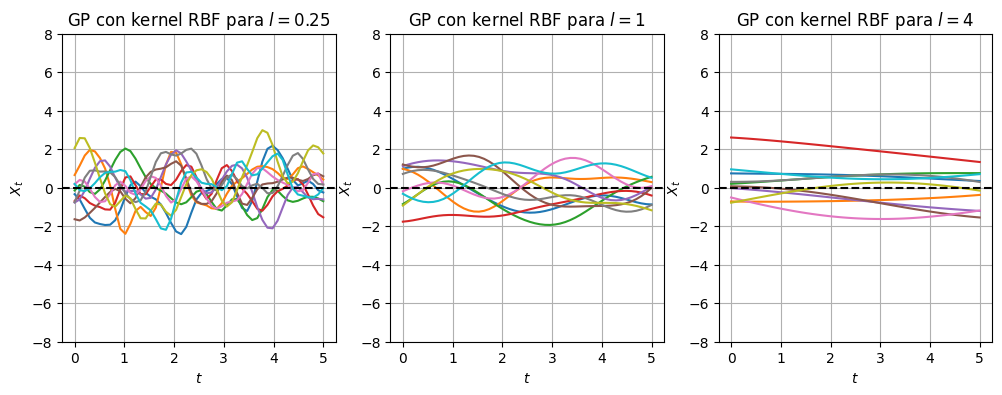

In [ ]:
# DIAPOSITIVA 62
# Ahora varía lengthscale y dejamos fijo el parámetro sigma

t = np.linspace(0,5,50)
sigma = 1
lengthscale1 = 0.25
lengthscale2 = 1
lengthscale3 = 4
num_samples = 10

# Visualización
plt.figure(figsize=(12,4))

plt.subplot(1,3,1) # Gráfica 1
samples1 = simular_GP_RBF(t, sigma, lengthscale1, num_samples)
for i in range(num_samples):
  plt.plot(t, samples1[i])

plt.grid(True)
plt.ylim(-8,8)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP con kernel RBF para $l=0.25$')

plt.subplot(1,3,2) # Gráfica 2
samples2 = simular_GP_RBF(t, sigma, lengthscale2, num_samples)
for i in range(num_samples):
  plt.plot(t, samples2[i])

plt.grid(True)
plt.ylim(-8,8)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP con kernel RBF para $l=1$')

plt.subplot(1,3,3) # Gráfica 3
samples3 = simular_GP_RBF(t, sigma, lengthscale3, num_samples)
for i in range(num_samples):
  plt.plot(t, samples3[i])

plt.grid(True)
plt.ylim(-8,8)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP con kernel RBF para $l=4$')


## 3. Visualizar un GP con kernel periódico

En esta sección se define una función `simular_GP_periodic`. A continuación se usará para generar imágenes similares a las de las diapositivas. Se usará función de medias constante igual a cero.

El kernel periódico viene definido como sigue:
$$
  k(t_1,t_2)=\sigma^2\exp(-\frac{2}{l^2}\sin^2(\pi\frac{|t_1-t_2|}{p}))
$$
donde los tres parámetros son: $\sigma^2$ la varianza, $l$ el lengthscale y $p$ el periodo.


In [ ]:
def simular_GP_periodic(t, sigma=1, lengthscale=1, period=1, num_samples=1):

  # Comprobación de que los datos proporcionados son correctos
  if t.ndim!=1:
    raise ValueError("t debe ser un vector")
  if sigma <= 0:
    raise ValueError("sigma_sq debe ser un valor positivo")
  if lengthscale <= 0:
    raise ValueError("lengthscale debe ser un valor positivo")
  if period <=0:
    raise ValueError("period debe ser un valor positivo")

  # Vector de medias
  vector_medias = np.zeros_like(t)

  # Caluclo la matriz de covarianzas
  d = t[:, None] - t[None, :]
  matriz_cov = sigma**2 * np.exp(-2/(lengthscale)**2 * np.sin(np.pi * d/period)**2)

  # Obtengo las simulaciones del GP
  samples = np.random.multivariate_normal(vector_medias, matriz_cov, num_samples)

  return samples


Visualizamos ahora algunas de las imágenes de las diapositivas:

Text(0.5, 1.0, 'GP periódico ($l=4$)')

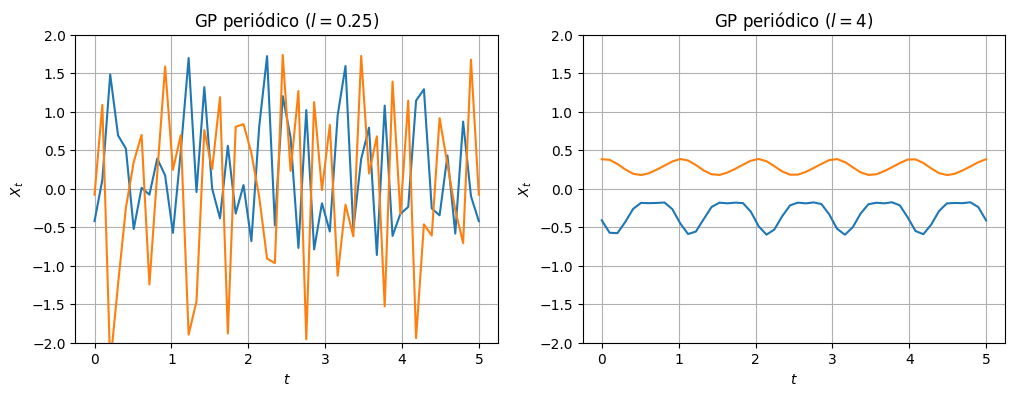

In [ ]:
# DIAPOSITIVA 72
t = np.linspace(0, 5, 50)
sigma = 1
lengthscale1 = 0.25
lengthscale2 = 4
period = 1
num_samples = 2

plt.figure(figsize=(12,4))

# Gráfica 1
plt.subplot(1,2,1)
samples1 = simular_GP_periodic(t, sigma, lengthscale1, period, num_samples)
for i in range(num_samples):
  plt.plot(t, samples1[i])

plt.grid(True)
plt.ylim(-2,2)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP periódico ($l=0.25$)')

# Gráfica 2
plt.subplot(1,2,2)
samples2 = simular_GP_periodic(t, sigma, lengthscale2, period, num_samples)
for i in range(num_samples):
  plt.plot(t, samples2[i])

plt.grid(True)
plt.ylim(-2,2)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP periódico ($l=4$)')

Text(0.5, 1.0, 'GP periódico ($p=2.5$)')

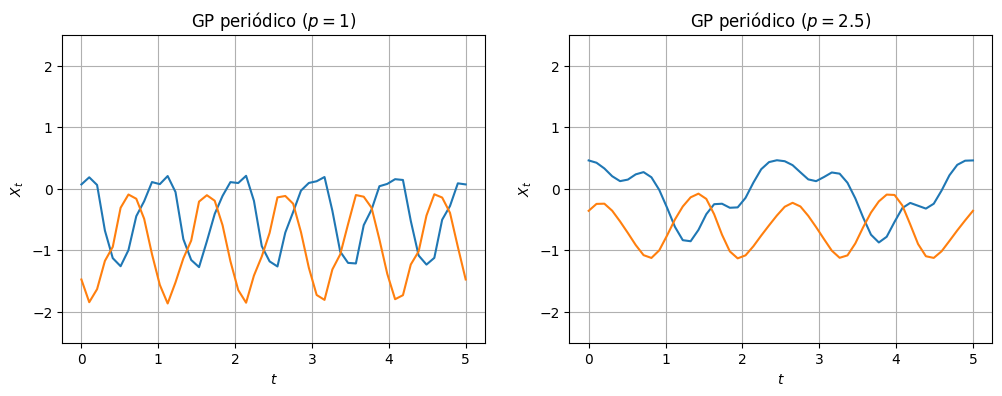

In [ ]:
# DIAPOSITIVA 74
t = np.linspace(0,5,50)
sigma = 1
lengthscale = 1
period1 = 1
period2 = 2.5
num_samples = 2

plt.figure(figsize=(12,4))
# Gráfica 1
plt.subplot(1,2,1)
samples1 = simular_GP_periodic(t, sigma, lengthscale, period1, num_samples)
for i in range(num_samples):
  plt.plot(t, samples1[i])

plt.grid(True)
plt.ylim(-2.5,2.5)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP periódico ($p=1$)')

# Gráfica 2
plt.subplot(1,2,2)
samples2 = simular_GP_periodic(t, sigma, lengthscale, period2, num_samples)
for i in range(num_samples):
  plt.plot(t, samples2[i])

plt.grid(True)
plt.ylim(-2.5,2.5)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP periódico ($p=2.5$)')

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3248/3463590588.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.title('GP periódico ($\sigma=1$)')
/tmp/ipykernel_3248/3463590588.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.title('GP periódico ($\sigma=4$)')


Text(0.5, 1.0, 'GP periódico ($\\sigma=4$)')

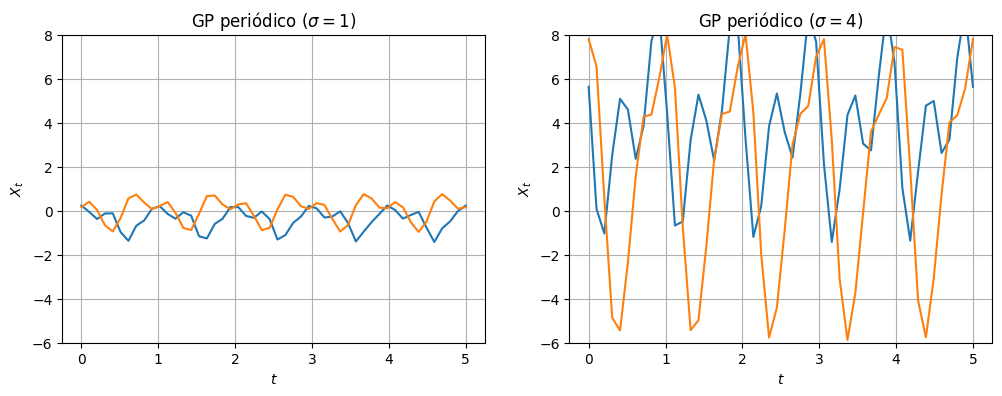

In [ ]:
# DIAPOSITIVA 76
t = np.linspace(0,5,50)
sigma1 = 1
sigma2 = 4
period = 1
lengthscale = 1
num_samples = 2

plt.figure(figsize=(12,4))
# Gráfica 1
plt.subplot(1,2,1)
samples1 = simular_GP_periodic(t, sigma1, lengthscale, period, num_samples)
for i in range(num_samples):
  plt.plot(t, samples1[i])

plt.grid(True)
plt.ylim(-6,8)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP periódico ($\sigma=1$)')

# Gráfica 2
plt.subplot(1,2,2)
samples2 = simular_GP_periodic(t, sigma2, lengthscale, period, num_samples)
for i in range(num_samples):
  plt.plot(t, samples2[i])

plt.grid(True)
plt.ylim(-6,8)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('GP periódico ($\sigma=4$)')

## 4. Simulación GP con kernel DPK (polinómico hasta grado $m$)

Vamos a definir una función `simular_GP_DPKpoly`. Concretamente vamos a simular un GP con kernel DPK que tenga funciones base $1,t,...,t^m$. A continuación, la usamos para generar imágenes similares a las de las diapositivas. Usaremos función de medias constantemente igual a cero.

Sean $f_1,...,f_m$ funciones de $T$ en $\mathbb{R}$. Se define el DPK asociado a $f_1,...,f_m$ como:
$$
  k(t_1,t_2)=\sum_{i=1}^m f_i(t_1)\cdot f_i(t_2)
$$

In [ ]:
def simular_GP_DPKpoly(t, m, num_samples):

  # Compruebo que los argumentos proporcionados son correctos
  if t.ndim != 1:
    raise ValueError("t debe de ser un vector")

  # Paso 1: calculo el vector de medias
  vector_medias = np.zeros_like(t)

  # Paso 2: calculo la matriz de covarianzas
  vector_potencias = np.arange(m+1)# vector con las potencias y dps hago broadcasting
  # salida: [0 1 ... m] que son las potencias
  # construyo el vector de funciones evaluado
  matriz_aux = t[:, None] ** vector_potencias
  # salida: [1 t_1 (t_1)^2 ... (t_1)^m]
  #         [1 t_2 (t_2)^2 ... (t_2)^m]
  #         ...
  #         [1 t_n (t_n)^2 ... (t_n)^m]

  matriz_cov = matriz_aux @ matriz_aux.T # mi matriz de covarianzas es el resultado de hacer el producto matricial de la matriz creada con su traspuesta
  # usar correcion de jitter.

  # Paso 3: obtención de las muestras
  samples = np.random.multivariate_normal(vector_medias, matriz_cov, num_samples)

  return samples


Visualizamos ahora la imagen de la diapositiva 89 usando la nueva función creada.

Text(0.5, 1.0, 'DPK kernel (m=3)')

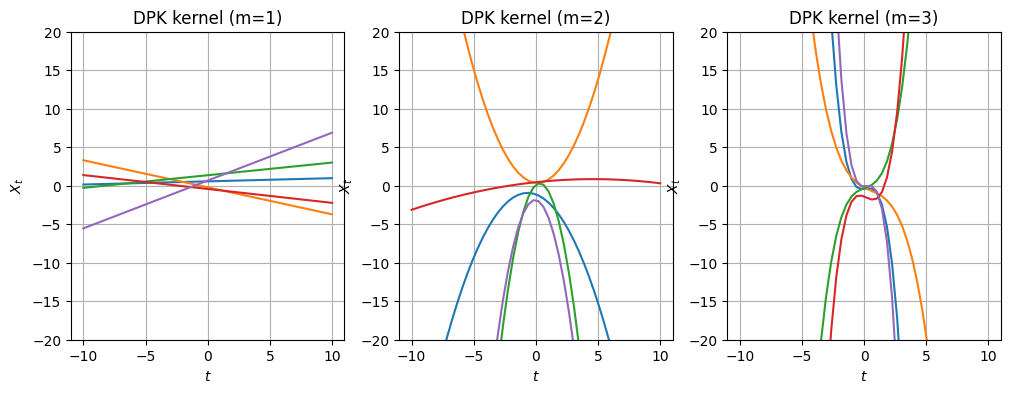

In [ ]:
# DIAPOSITIVA 89
t = np.linspace(-10, 10, 50)
m1 = 1
m2 = 2
m3 = 3
num_samples = 5

plt.figure(figsize=(12,4))
# Gráfica 1
plt.subplot(1,3,1)
samples1 = simular_GP_DPKpoly(t, m1, num_samples)
for i in range (num_samples):
  plt.plot(t, samples1[i])

plt.grid(True)
plt.ylim(-20,20)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('DPK kernel (m=1)')

# Gráfica 2
plt.subplot(1,3,2)
samples2 = simular_GP_DPKpoly(t, m2, num_samples)
for i in range(num_samples):
  plt.plot(t, samples2[i])

plt.grid(True)
plt.ylim(-20,20)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('DPK kernel (m=2)')

# Gráfica 3
plt.subplot(1,3,3)
samples3 = simular_GP_DPKpoly(t, m3, num_samples)
for i in range(num_samples):
  plt.plot(t, samples3[i])

plt.grid(True)
plt.ylim(-20,20)
plt.xlabel('$t$')
plt.ylabel('$X_t$')
plt.title('DPK kernel (m=3)')


## 5. ¿Cómo hacer que el kernel se pase como parámetro? ¿Y la función de medias?

En esta sección se presenta muy brevemente una solución basada en el paradigma de programación orientada a objetos (POO).

La idea de la POO es estructurar el código usando el concepto de _clase_. Concretamente, una _clase_ es una estructura que nos permite crear objetos que contienen dos cosas principalmente:
* Atributos: valores que forman parte del objeto.
* Métodos: acciones que puede realizar el objeto.

A continuación definimos una _clase_ para describir el kernel RBF. La clase define dos atributos:
* ```self.sigma_sq```: es el parámetro $\sigma^2$.
* ```self.lengthscale```: es el parámetro $\ell$.
Y la clase define un método (además del ```__init__``` básico, que se usa para crear un objeto de la clase):
* ```__call__(self, t, s)```: permite evaluar el kernel usando como inputs los arrays t y s. Es decir, calcula la matriz $(k(t_i, s_j))_{ij}$.

In [ ]:
class RBF:
  def __init__(self, sigma_sq=1, lengthscale=1):
    self.sigma_sq = sigma_sq
    self.lengthscale = lengthscale
  def __call__(self, t, s):
    dists = t[:, None] - s[None, :]
    cov_matrix = self.sigma_sq * np.exp(-0.5 * (dists / self.lengthscale)**2)
    return cov_matrix

In [ ]:
# Usamos la clase recién definida para crear un objeto de este tipo:

my_kernel = RBF(sigma_sq=1, lengthscale=1)
print(type(my_kernel))  # Deberíamos ver que este objeto es de tipo "RBF"

t = np.linspace(0,10,100)
cov_mat = my_kernel(t,t)   # Aquí estamos usando el método __call__ (es un método especial que se utiliza de esta manera)
print(cov_mat.shape)  # Aquí deberíamos obtener una matriz con shape (100, 100), puesto que es la matriz de covarianzas de evaluar el GP en t (que tiene tamaño 100)

<class '__main__.RBF'>
(100, 100)


In [ ]:
# Se define ahora una clase para la función de medias constantemente igual a cero:
class Zero_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return np.zeros_like(t)

# Creamos un objeto de ese tipo:
my_mf = Zero_Mean_Function()
print(type(my_mf))

mean = my_mf(t)
print(mean.shape)
print((mean==0).all())

Definimos ahora una función ```simular_GP``` que recibe como parámetros __cualquier función de medias__ (```mf```) y __cualquier kernel__ (```kernel```). Lo único que necesitamos es que sean objetos de clases en las que se haya definido el método ```__call__``` igual que se ha hecho arriba.

In [ ]:
def simular_GP(t, mf, kernel, num_samples=1):
  vector_medias = mf(t)
  matriz_covs = kernel(t,t)
  samples = np.random.multivariate_normal(vector_medias, matriz_covs, num_samples)  # Shape: (num_samples, n)
  return samples

Para validar esta función, vamos a generar la imagen de la diapositiva 64, donde se usaba la función de medias identidad y el kernel RBF.

Para ello, definimos una clase para la función de medias identidad:

In [ ]:
class Identity_Mean_Function:
  def __init__(self):
    pass
  def __call__(self, t):
    return t

Finalmente, usamos esta clase, la clase RBF, y la función ```simular_GP``` para obtener lo buscado:

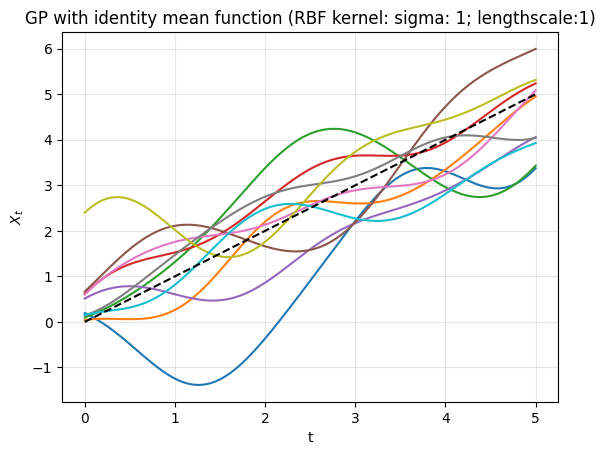

In [ ]:
my_identity_mf = Identity_Mean_Function()
sigma = 1
lengthscale = 1
my_rbf_kernel = RBF(sigma_sq=sigma**2, lengthscale=lengthscale)
t = np.linspace(0,5,500)
num_samples = 10
samples = simular_GP(t, my_identity_mf, my_rbf_kernel, num_samples=num_samples)

for i in range(num_samples):
  plt.plot(t, samples[i,:])
plt.plot(t, my_identity_mf(t), color='black', linestyle="--")
plt.title(f"GP with identity mean function (RBF kernel: sigma: {sigma}; lengthscale:{lengthscale})")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.grid(True, alpha=0.3)
plt.show()